## Подготовка данных для обучения

Когда человека просят освоить новое дело, он обычно просит показать пример. С LLM то же самое: перед обучением мы готовим датасет с правильными примерами, на которых модель учится.

Возьмём фразу:

`"Кот очень любит свежую ..."`

То каким образом LLM поймет, что за словом «свежую» идет слово «сметану»? Правильно, **никак**.

Но если мы покажем пример: **«Кот очень любит свежую сметану»**, то появится некая связь. А если мы покажем тысячи таких примеров, то, конечно, связь будет достаточная, чтобы LLM могла предсказать, что за словом «свежую» идет слово «сметану».

На прошлом этапе мы получили идентификаторы токенов, а в этом нам необходимо подготовить данные для обучения с помощью алгоритма Скользящее окно, где мы будем создавать пары - «входные данные - цель».

## Что мы хотим получить?

Прежде чем писать код, давайте договоримся о цели. Представьте, что вы учите ребёнка читать. Вы показываете ему начало предложения и просите угадать следующее слово:

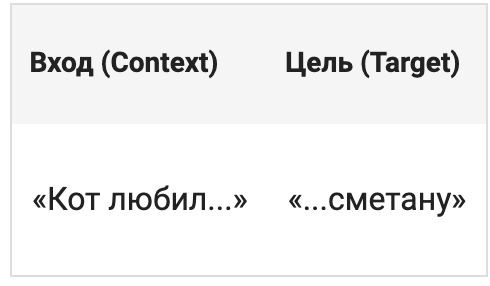

Для нейросети это выглядит точно так же, только **вместо слов она видит числа** (ID токенов), сейчас сами числа не важны:

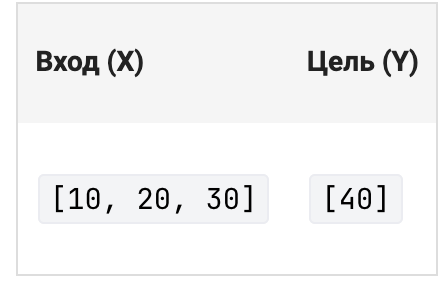

Модель смотрит на «Вход», пытается угадать «Цель», ошибается, корректирует свои веса и учится снова.

**Рассмотрим простой пример:**

У нас есть длинный список токенов: `[A, B, C, D, E, F, G ...]`

Нам нужно создать пары (Вход, Цель). Допустим, мы решили, что модель будет смотреть на **4** токена подряд, чтобы угадать **5-й**.

**Шаг 1:**

Вход: [A, B, C, D]

Цель: [E] (то, что идет сразу после D)


**Шаг 2 (Сдвигаем окно на 1 позицию вправо):**

Вход: [B, C, D, E]

Цель: [F]


**Шаг 3 (Сдвигаем еще на 1):**

Вход: [C, D, E, F]

Цель: [G]

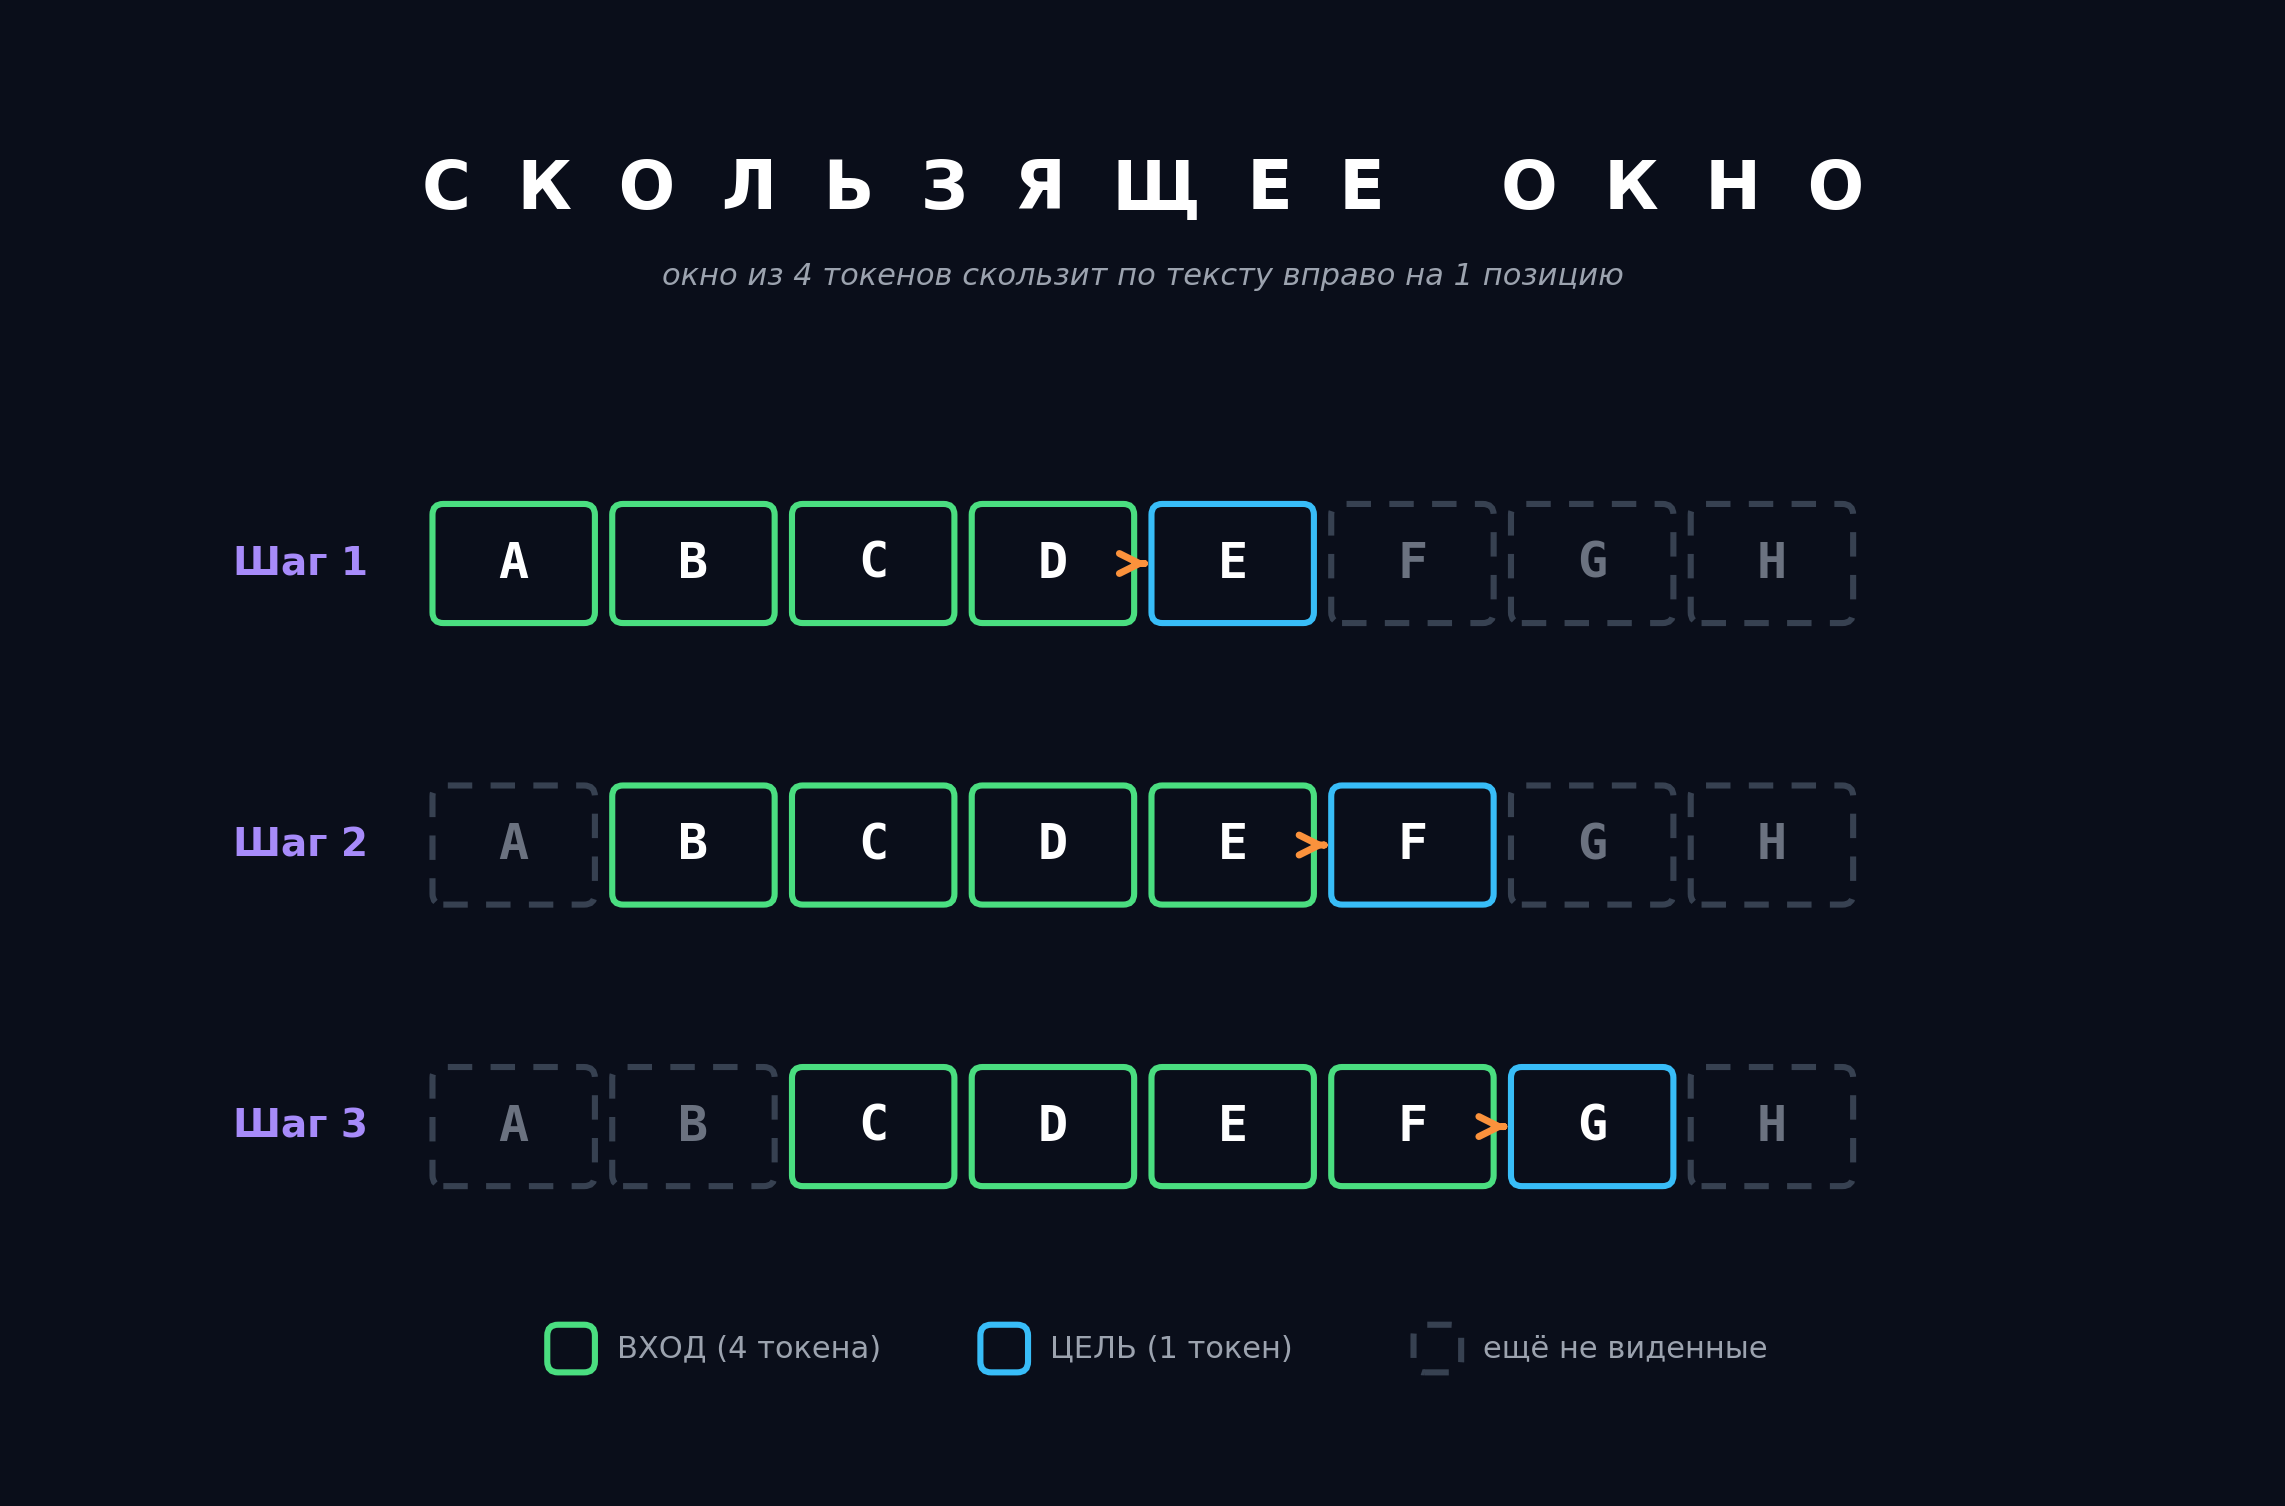

Псевдокод на Python:

In [ ]:
context_size = 4
tokens = [290, 4920, 2241, 287, 257, 6232, 318]

# Шаг 1: окно стоит в начале, цель - токен сразу после окна
x = tokens[0:context_size]   # [290, 4920, 2241, 287]
y = tokens[context_size]     # 257

# Шаг 2: сдвигаем окно на 1 позицию вправо
x = tokens[1:context_size + 1]   # [4920, 2241, 287, 257]
y = tokens[context_size + 1]     # 6232

# Шаг 3: ещё один сдвиг
x = tokens[2:context_size + 2]   # [2241, 287, 257, 6232]
y = tokens[context_size + 2]     # 318

Логика простая: каждый раз срезаем из ленты токенов кусок длиной context_size, а целью берём следующий за ним токен.



Это называется **авторегрессивное обучение**. Модель учится предсказывать продолжение на основе всего, что было до этого. Сначала только на основе одного токена, потом двух, потом трёх - и так до полного окна.

Растущий контекст для интуиции можно записать так:

[290]                       → 4920

[290, 4920]                 → 2241

[290, 4920, 2241]           → 287

[290, 4920, 2241, 287]      → 257

Здесь модель видит, как от шага к шагу контекст растёт и каждый раз нужно угадать следующее число. Удобно для понимания, но неудобно для GPU: видеокарте не нравится, когда каждый пример имеет свою длину.

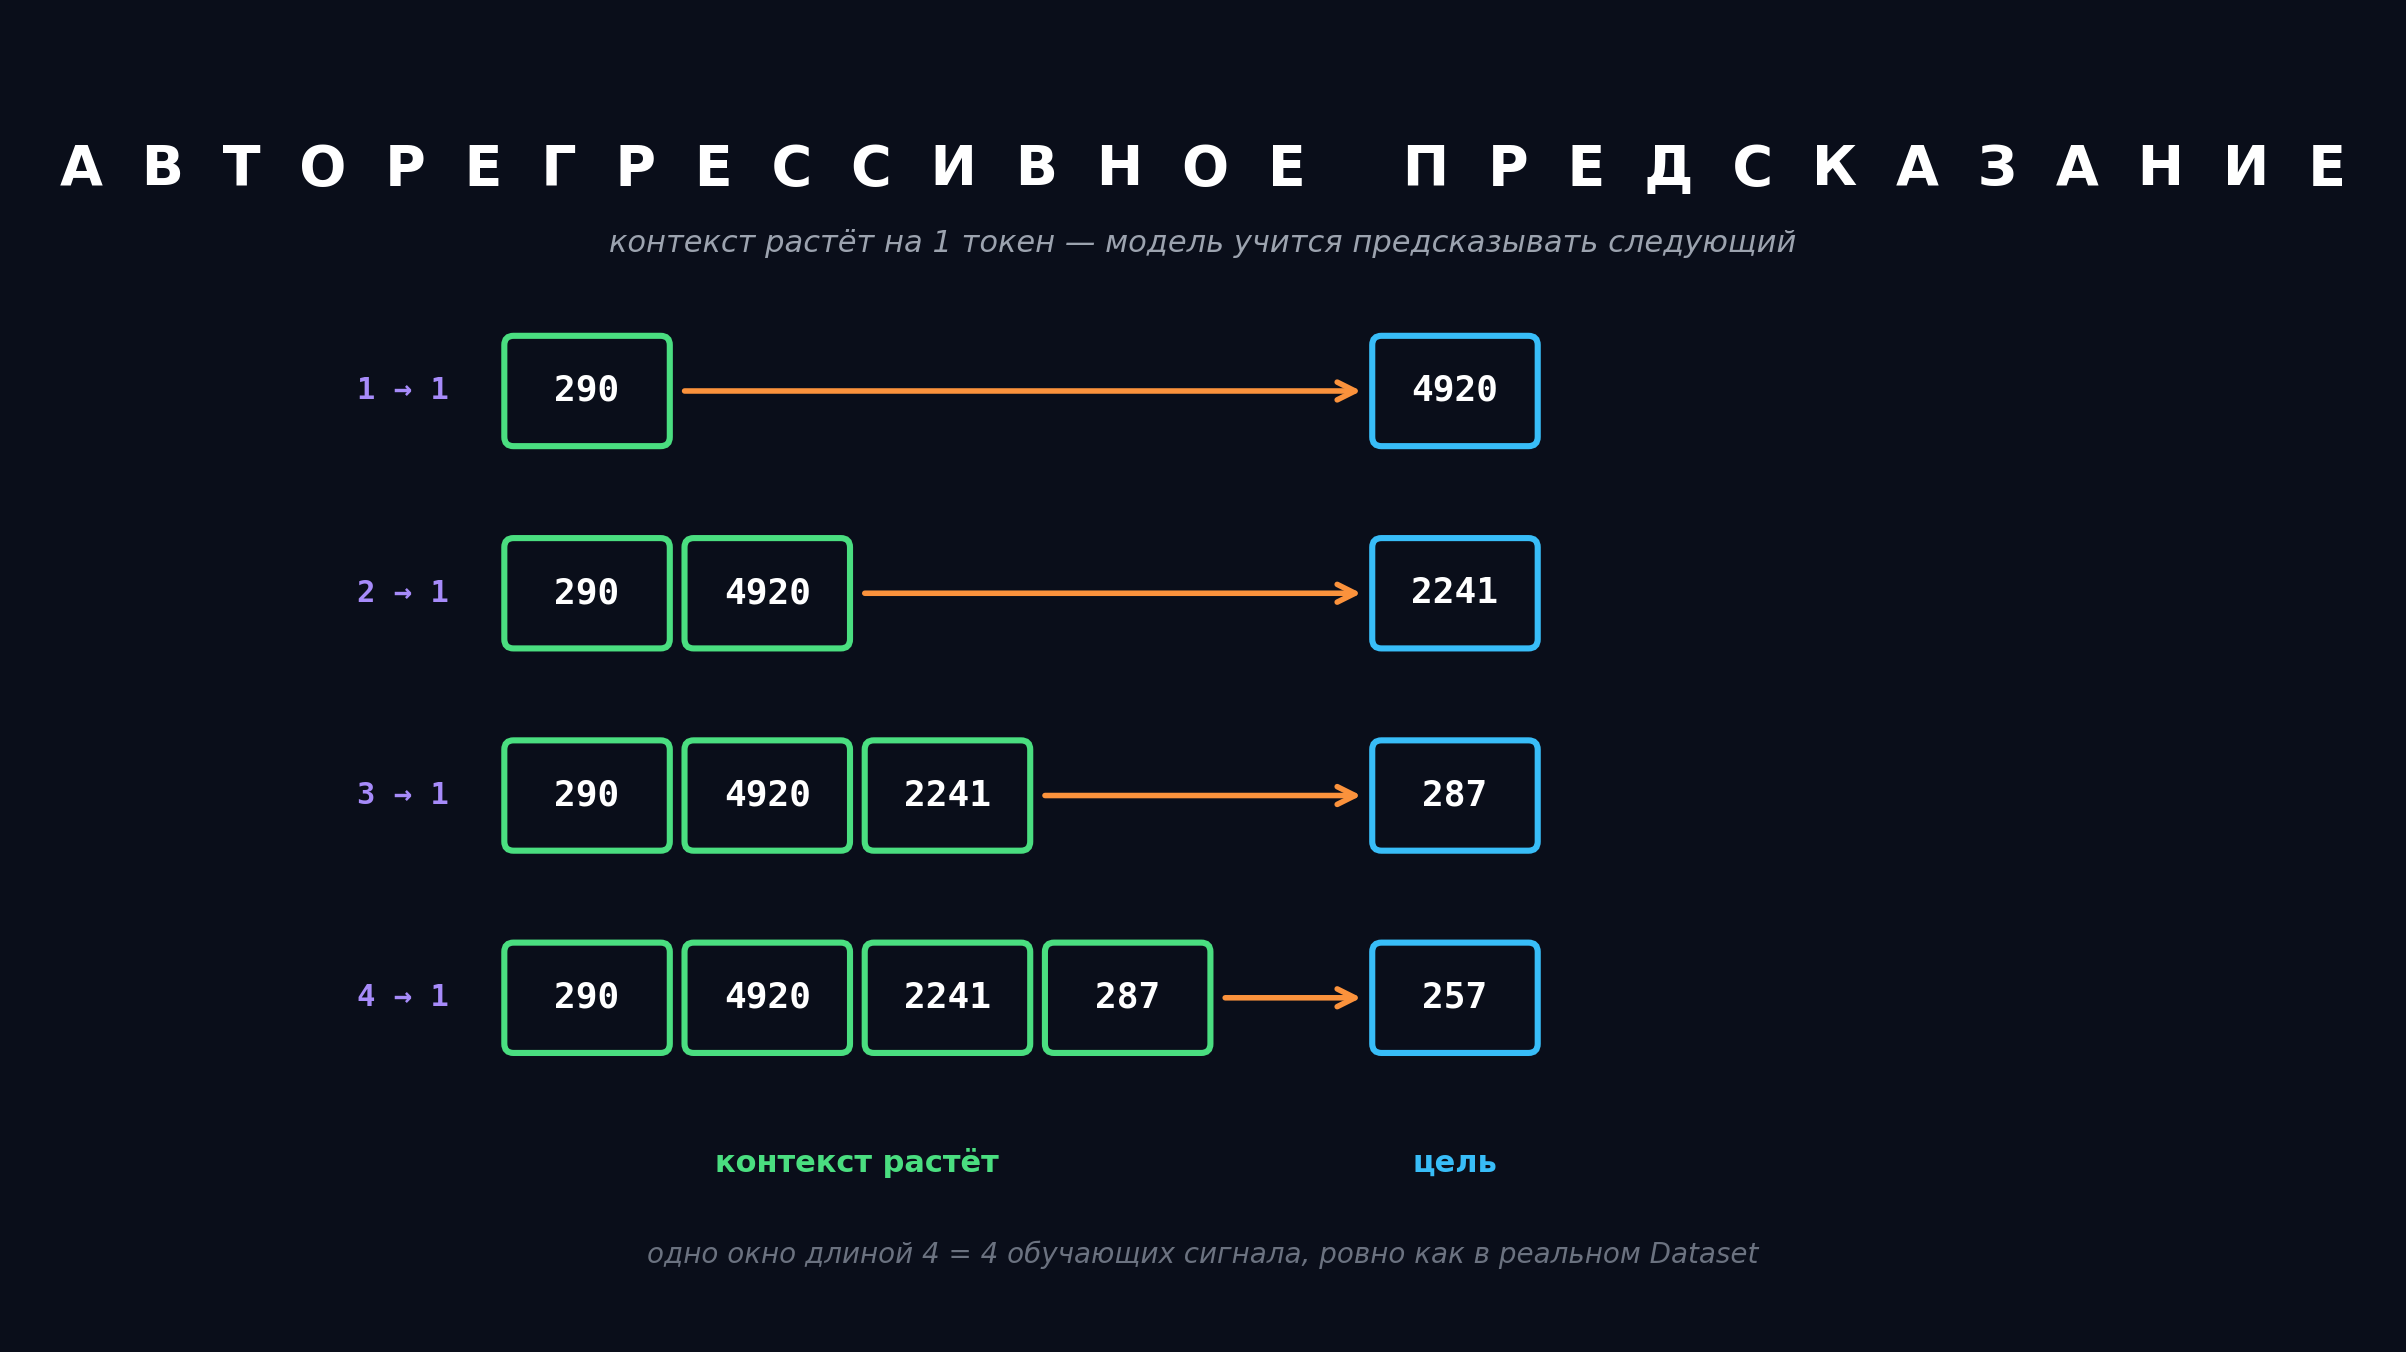

## Создаём наш первый учебный датасет

Для всех примеров этой главы мы создадим простой текстовый файл `cat_story.txt`

Первый шаг - превратить этот текст в идентификаторы токенов (IDs). Для этого используем токенизатор transformers от Hugging Face, так же, как мы делали на первом этапе, только текст теперь будем считывать из файла cat_story.txt и использовать токенизатор gpt2. В модуле 5 мы брали ai-forever/rugpt3small_based_on_gpt2 для русского текста, а здесь текст английский, поэтому берём gpt2.

Создаём новый файл `tokenizer.py`

## Применяем метод «Скользящее окно»

У нас есть длинная цепочка токенов:

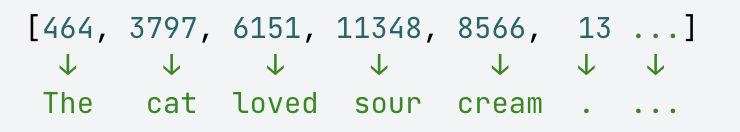

Модель не может «съесть» весь текст сразу. Нам нужно создать много пар «Вход → Цель» из этой одной цепочки.

Добавляем код для сдвига в наш файл `tokenizer.py` (добавляем контекстное окно)

**Обратите внимание:**

- Всё, что слева от стрелки → - это входные данные модели
- Токен справа от стрелки - это цель, которую модель должна предсказать
- С каждым шагом контекст растёт на 1 токен

В нашем примере с «растущим контекстом» ([A] → B, [A, B] → C) мы показали принцип авторегрессии. Это идеально для понимания того, как модель думает. Но для обучения на видеокарте (GPU) нам нужно немного иначе.

**Почему?** Представьте, что вы хотите перевезти кирпичи.

- Вариант «Растущий контекст»: Ты берешь 1 кирпич, везешь. Потом 2 кирпича, везешь. Потом 3... Видеокарте неудобно каждый раз перестраивать «кузов» под разное количество кирпичей.
- Вариант «Фиксированный контекст»: Ты берешь всегда по 10 кирпичей в ящике. Это стандартный размер. Видеокарта любит стандартные размеры (тензоры одинаковой формы).


**Поэтому в реальном коде Dataset мы будем использовать фиксированный размер окна (например, 4 токена вход, 4 токена цель), но будем сдвигать это окно по всему тексту.**

Вы можете спросить: «ну сделал я списки списков, и что дальше?». Но есть важный момент - нейросети работают на GPU (видеокартах). Видеокарты отлично работают с тензорами, а не с разными по длине списками Python.

Кроме того, обучать модель по одному примеру за раз - очень долго. Мы хотим скармливать ей данные **пакетами (batches)**. Например, сразу 8 примеров обучения.

Для этого в библиотеке PyTorch (на которой построено большинство современных LLM, включая многие модели Hugging Face) есть два важных класса:

- **Dataset**: Это хранилище твоих данных. Оно говорит: «У меня есть вот такой текст, и я умею отдавать его кусочки по запросу».
- **DataLoader**: Это «грузчик». Он берет данные из Dataset, собирает их в пакеты (batches), перемешивает (если нужно) и передает модели.

Напишем простой класс `SimpleDataset` в `simple_dataset.py`

Давайте разберем этот код детально, так как здесь скрыта вся магия подготовки данных.

1. Инициализация (__init__): Мы принимаем сырой текст, токенизатор и два гиперпараметра: max_length и stride.

- max_length: Сколько токенов модель видит за один раз (размер окна).
- stride: На сколько токенов мы сдвигаем окно после каждого примера.
  - Если stride = max_length, куски не пересекаются (эффективное использование данных, но меньше примеров).
  - Если stride = 1, мы используем скользящее окно с шагом в 1 токен (максимум данных, но много повторений). Для обучения обычно используют stride = max_length или половину от него.

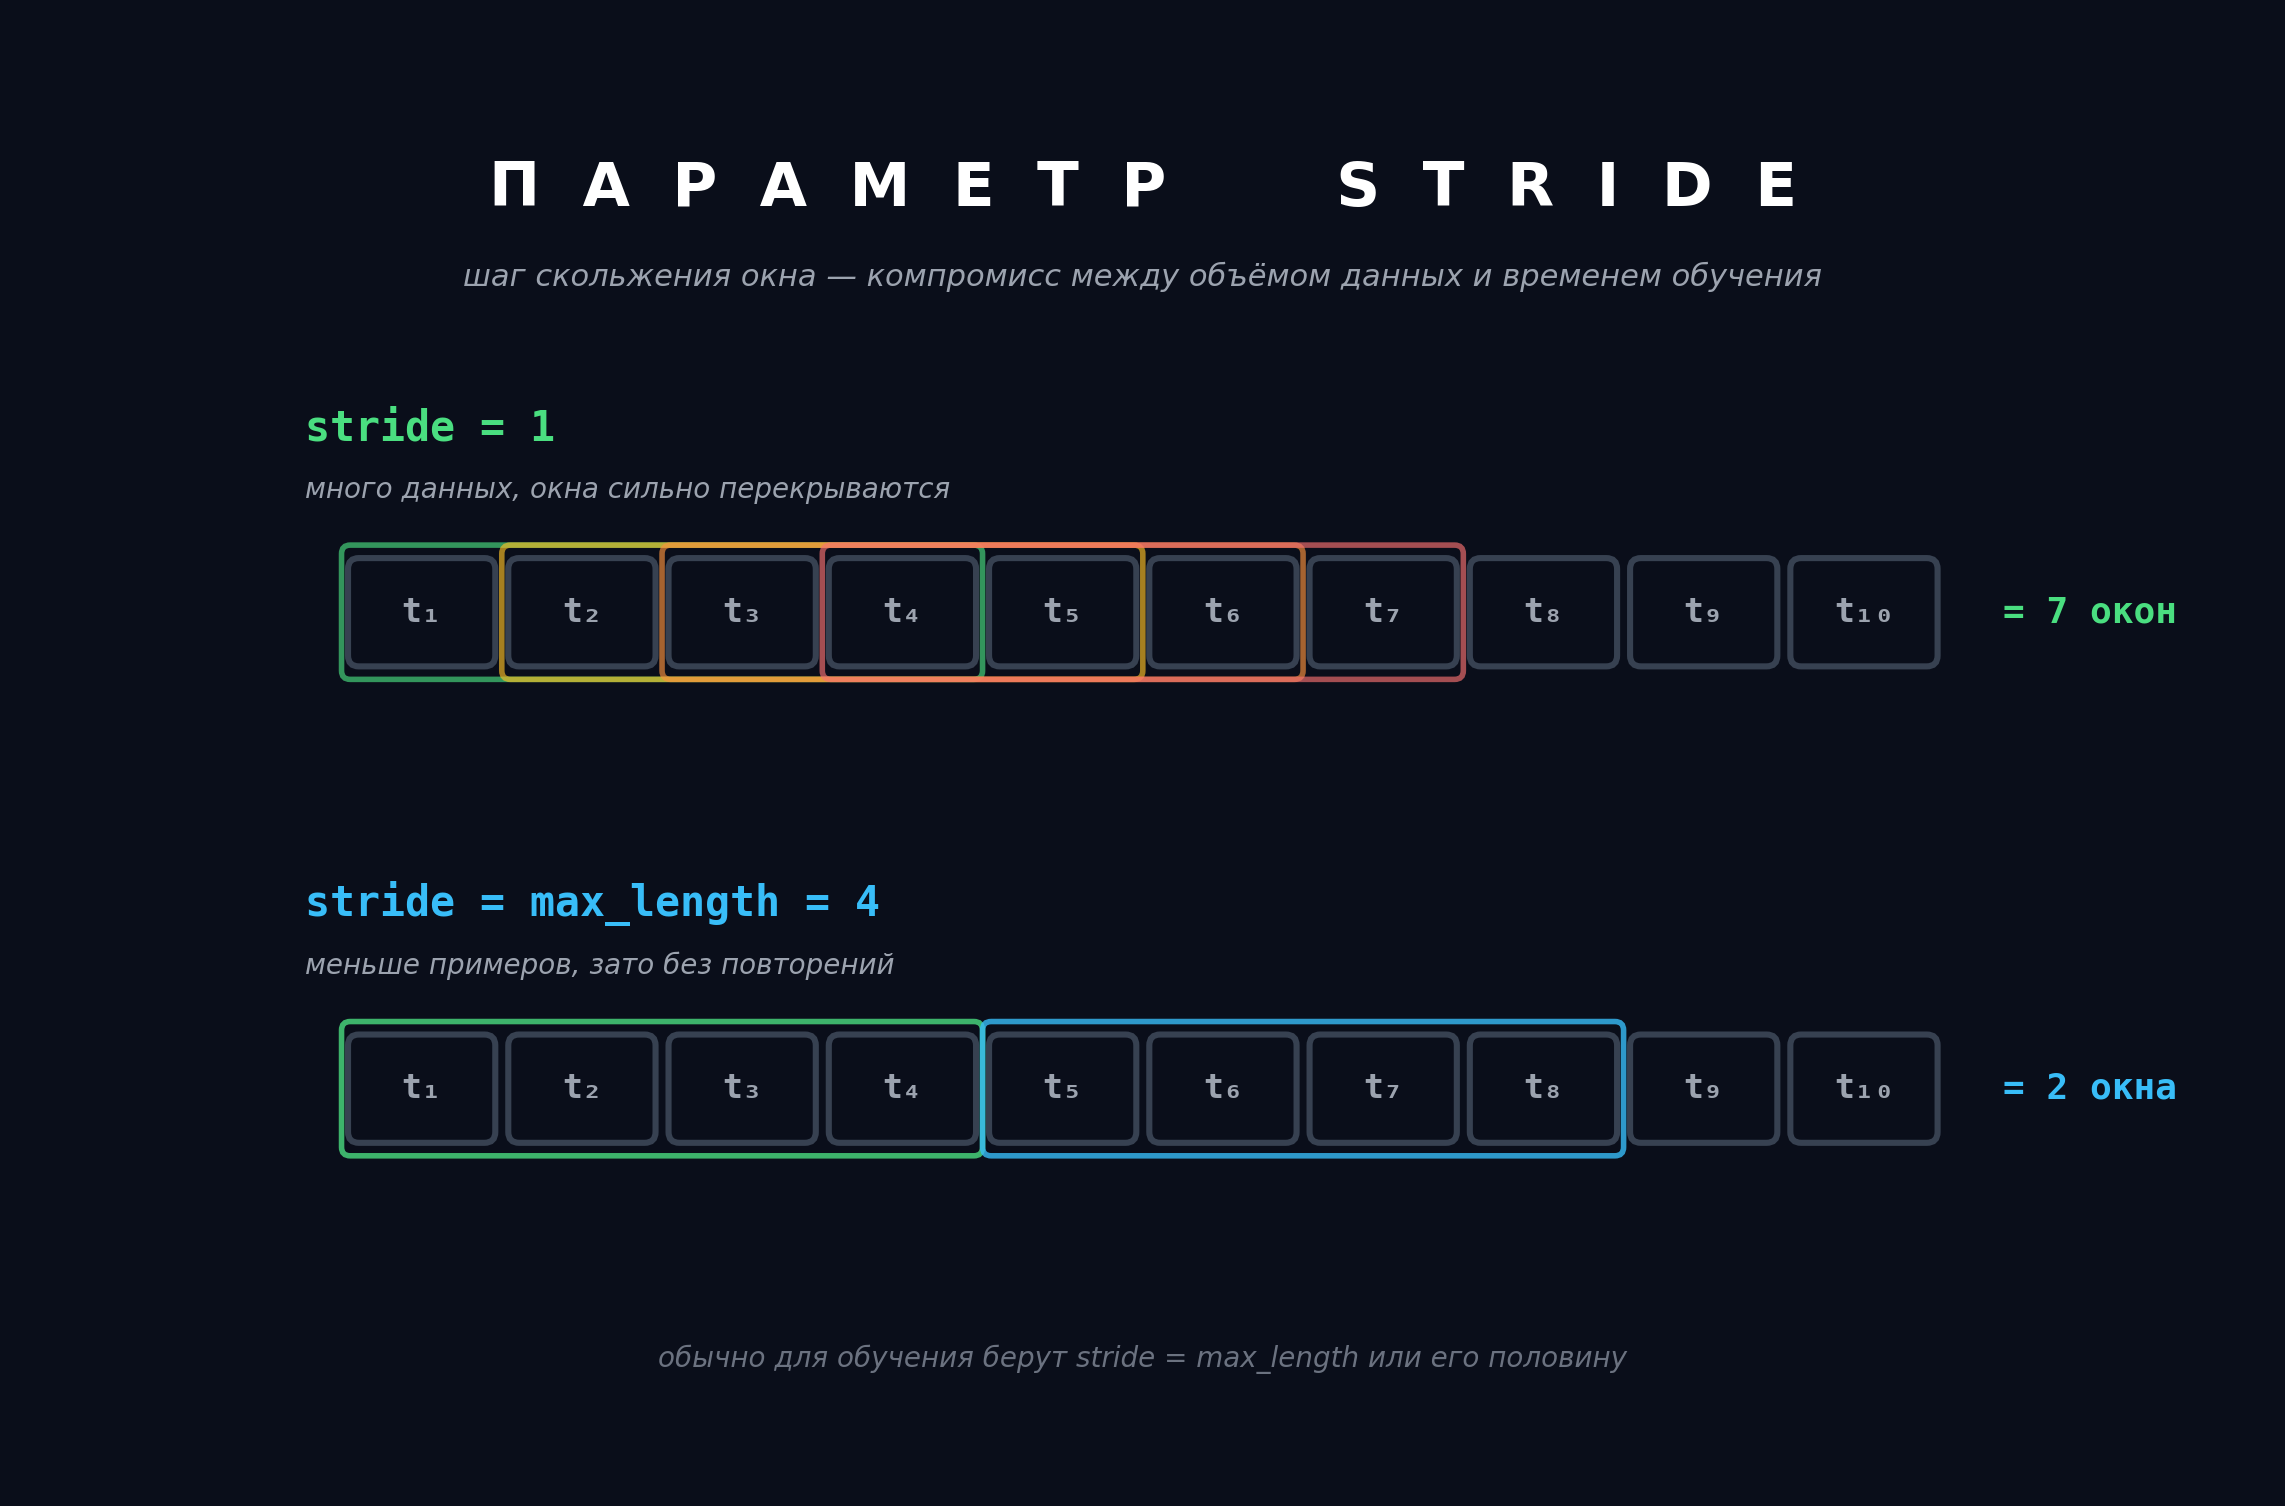

2. Длина датасета (__len__): PyTorch должен знать, сколько раз он может вызвать __getitem__, прежде чем данные закончатся (это называется эпохой). Мы вычисляем это математически, чтобы не создавать огромный список в памяти заранее.

3. Получение элемента (__getitem__): Это сердце класса. Когда DataLoader просит пример номер idx, мы:

    1. Считаем, где начинается этот кусок в общем потоке токенов (start_idx).
    2. Вырезаем max_length токенов для входа (chunk).
    3. Вырезаем целевые токены (targets). Обратите внимание: targets сдвинуты на 1 позицию вперед относительно chunk. Это реализует тот самый принцип «предскажи следующее слово», о котором мы говорили в начале.
    4. Возвращаем данные сразу в виде тензоров PyTorch.

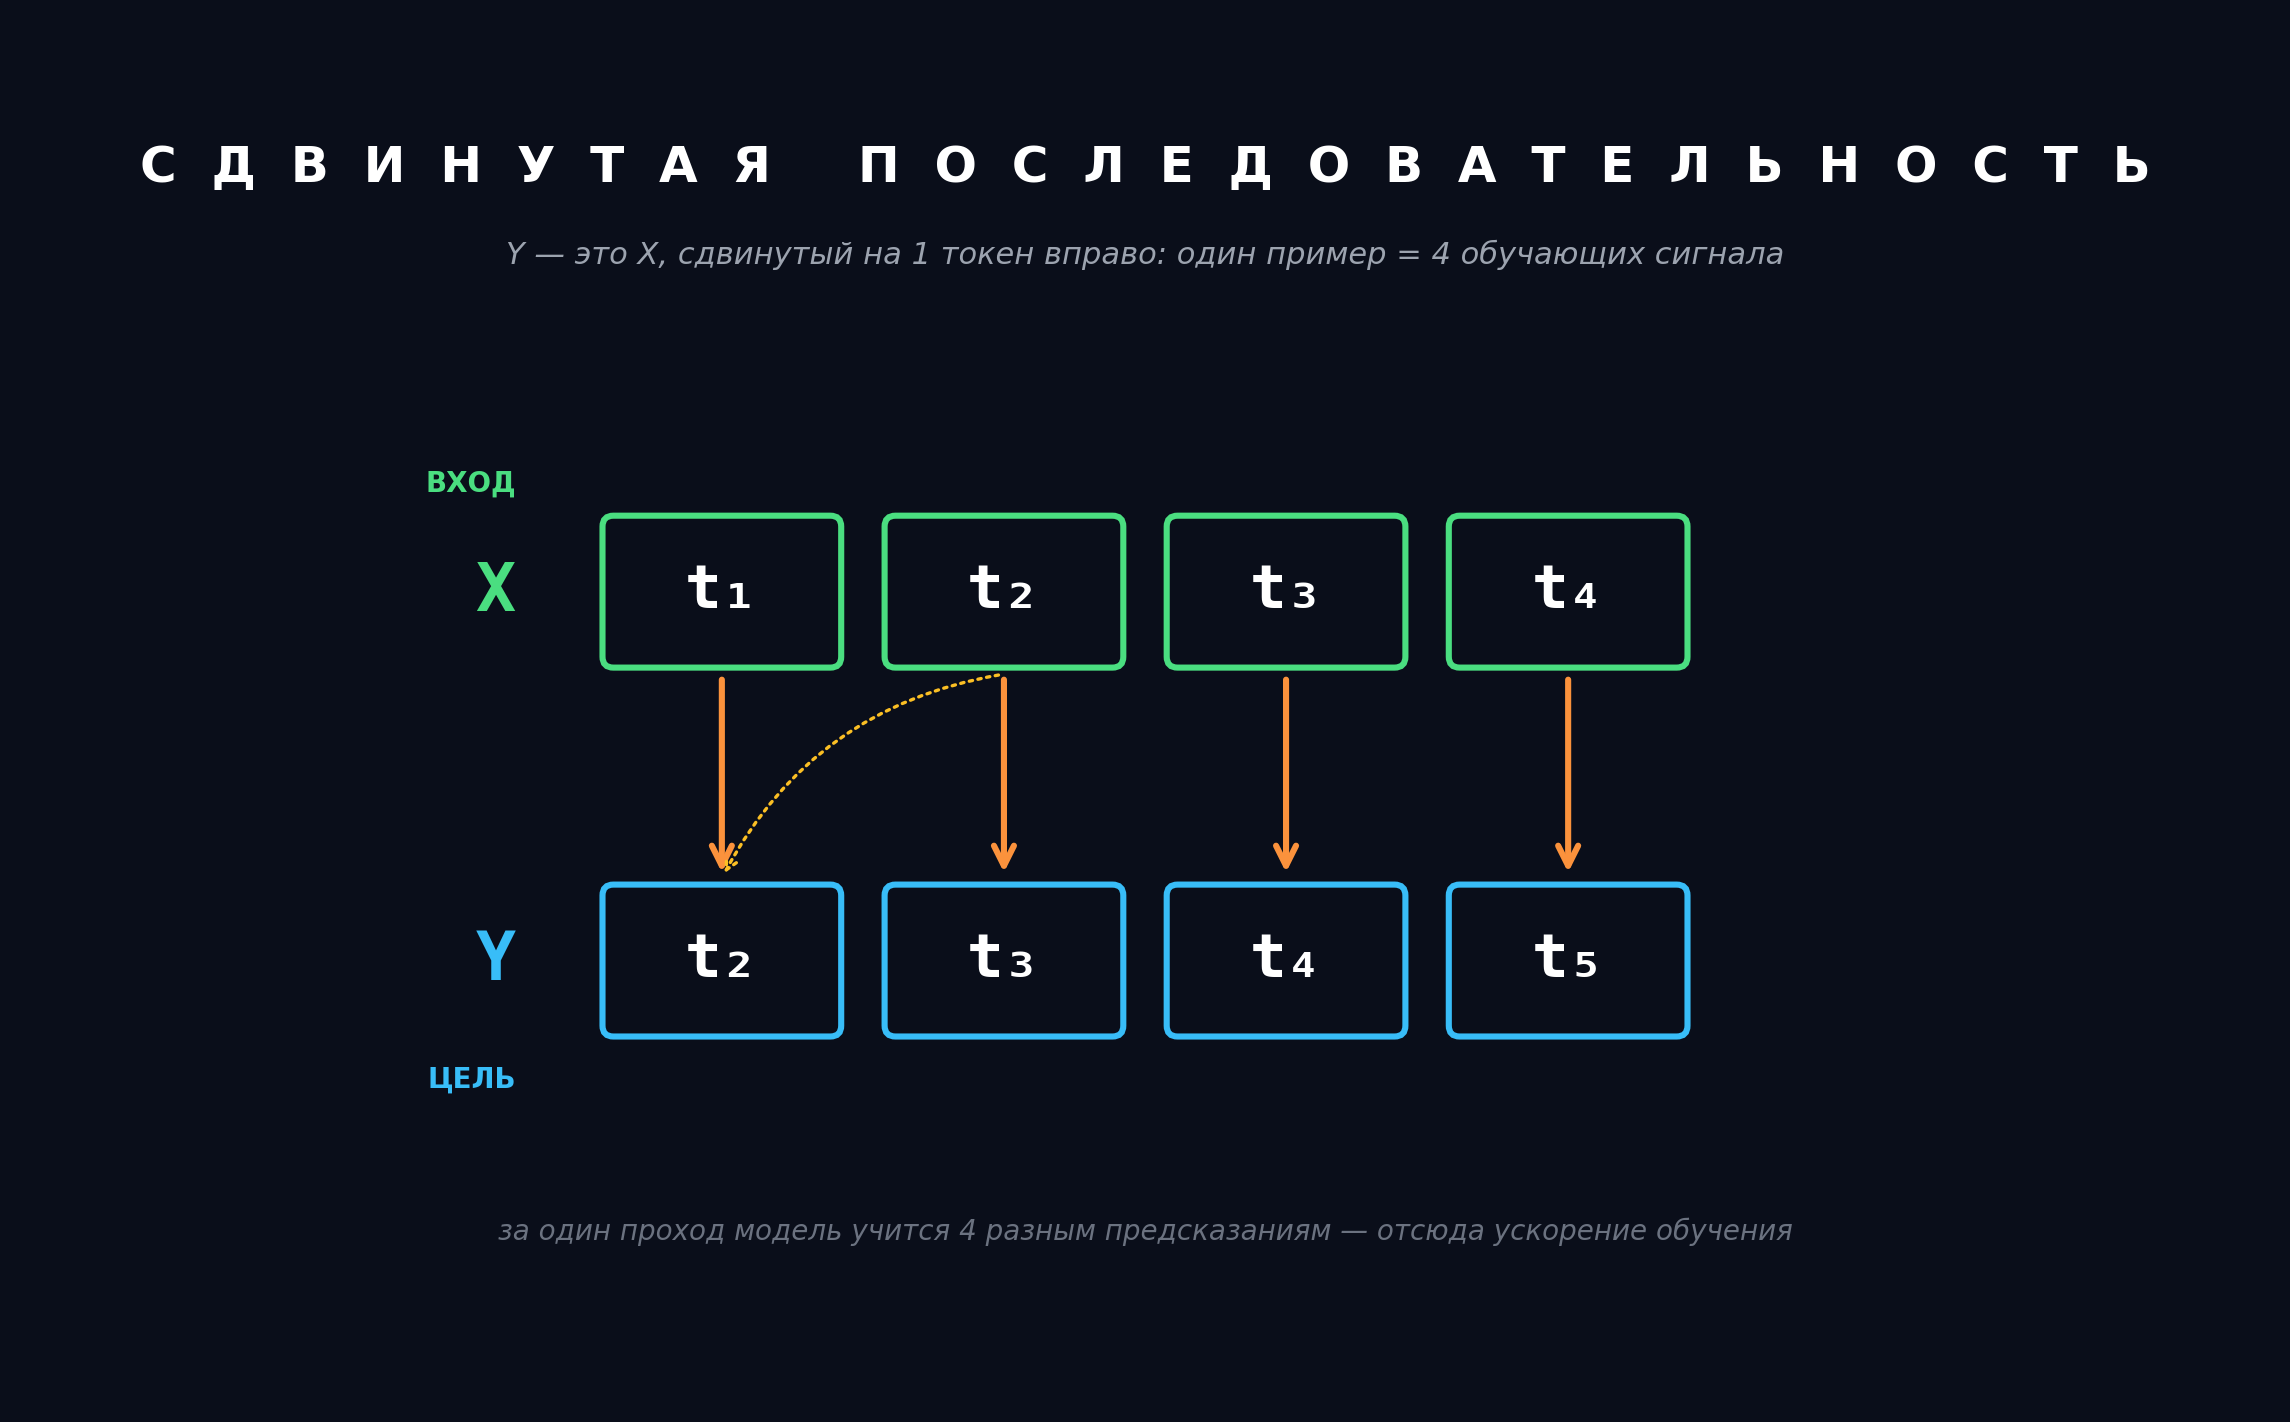

## Собираем всё вместе: DataLoader

Теперь, когда у нас есть «хранилище» (Dataset), нам нужен «грузчик» (DataLoader). Он возьмет на себя задачу собирать отдельные примеры в пакеты (batches) и перемешивать их.

Переходим в наш файл `tokenizer.py`

Добавляем импорты и новый код.

1. Размерность [2, 4]: У нас 2 примера в пакете (batch_size=2), и в каждом примере по 4 токена (max_length=4). Это идеальная матрица для видеокарты.
2. Сдвиг данных: Посмотрите на первую строку X и Y.

X[0]: [464, 3797, 6151, 11348] (The cat loved sour)

Y[0]: [3797, 6151, 11348, 8566] (cat loved sour cream)

Видно, что Y - это X, сдвинутый влево на одну позицию. Модель учится: видя "The", предсказать "cat"; видя "The cat", предсказать "loved" и так далее.

3. Второй пример в пакете: Вторая строка тензора - это следующий сдвиг окна в тексте. Поскольку stride=1, второй пример начинается со второго токена первого примера.

Теперь представьте, что у вас не 66 токенов, а миллионы (как в Википедии).

Без Dataset и DataLoader вам пришлось бы загружать всё в память сразу, что невозможно.
Без батчей (batching) обучение шло бы крайне медленно, так как видеокарта простаивала бы, обрабатывая по одному числу за раз.

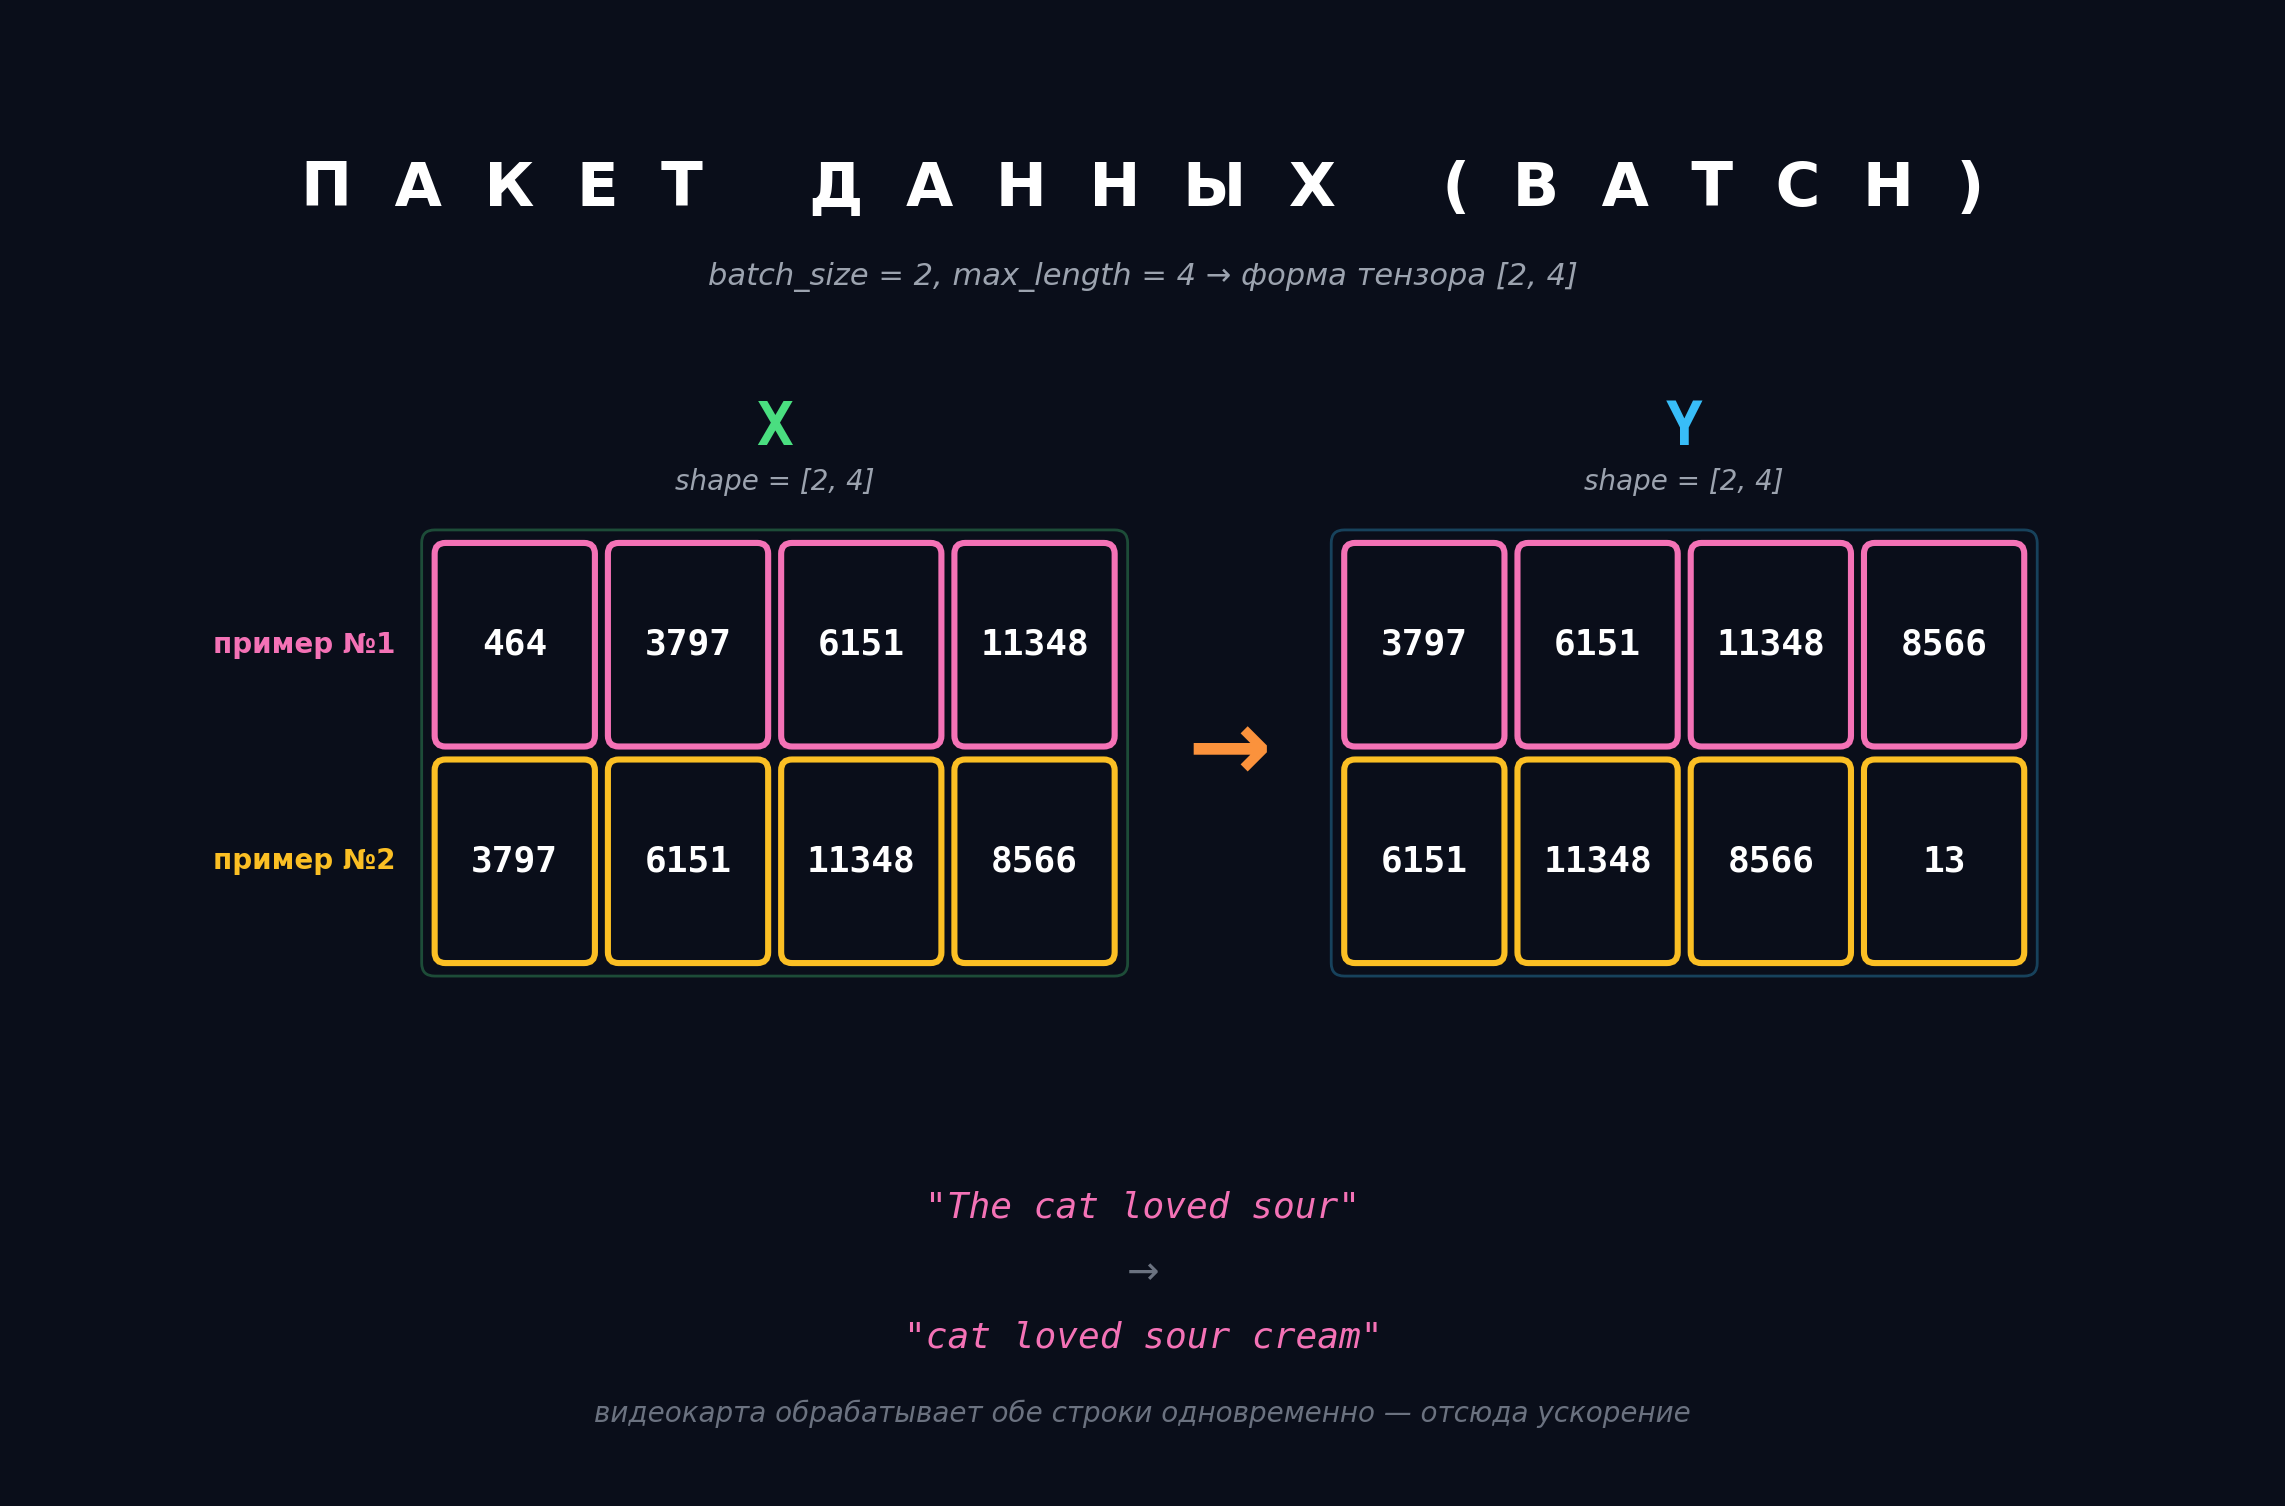

Мы создали конвейер (pipeline), который превращает сырой текст в математические объекты, готовые для отправки в нейросети.


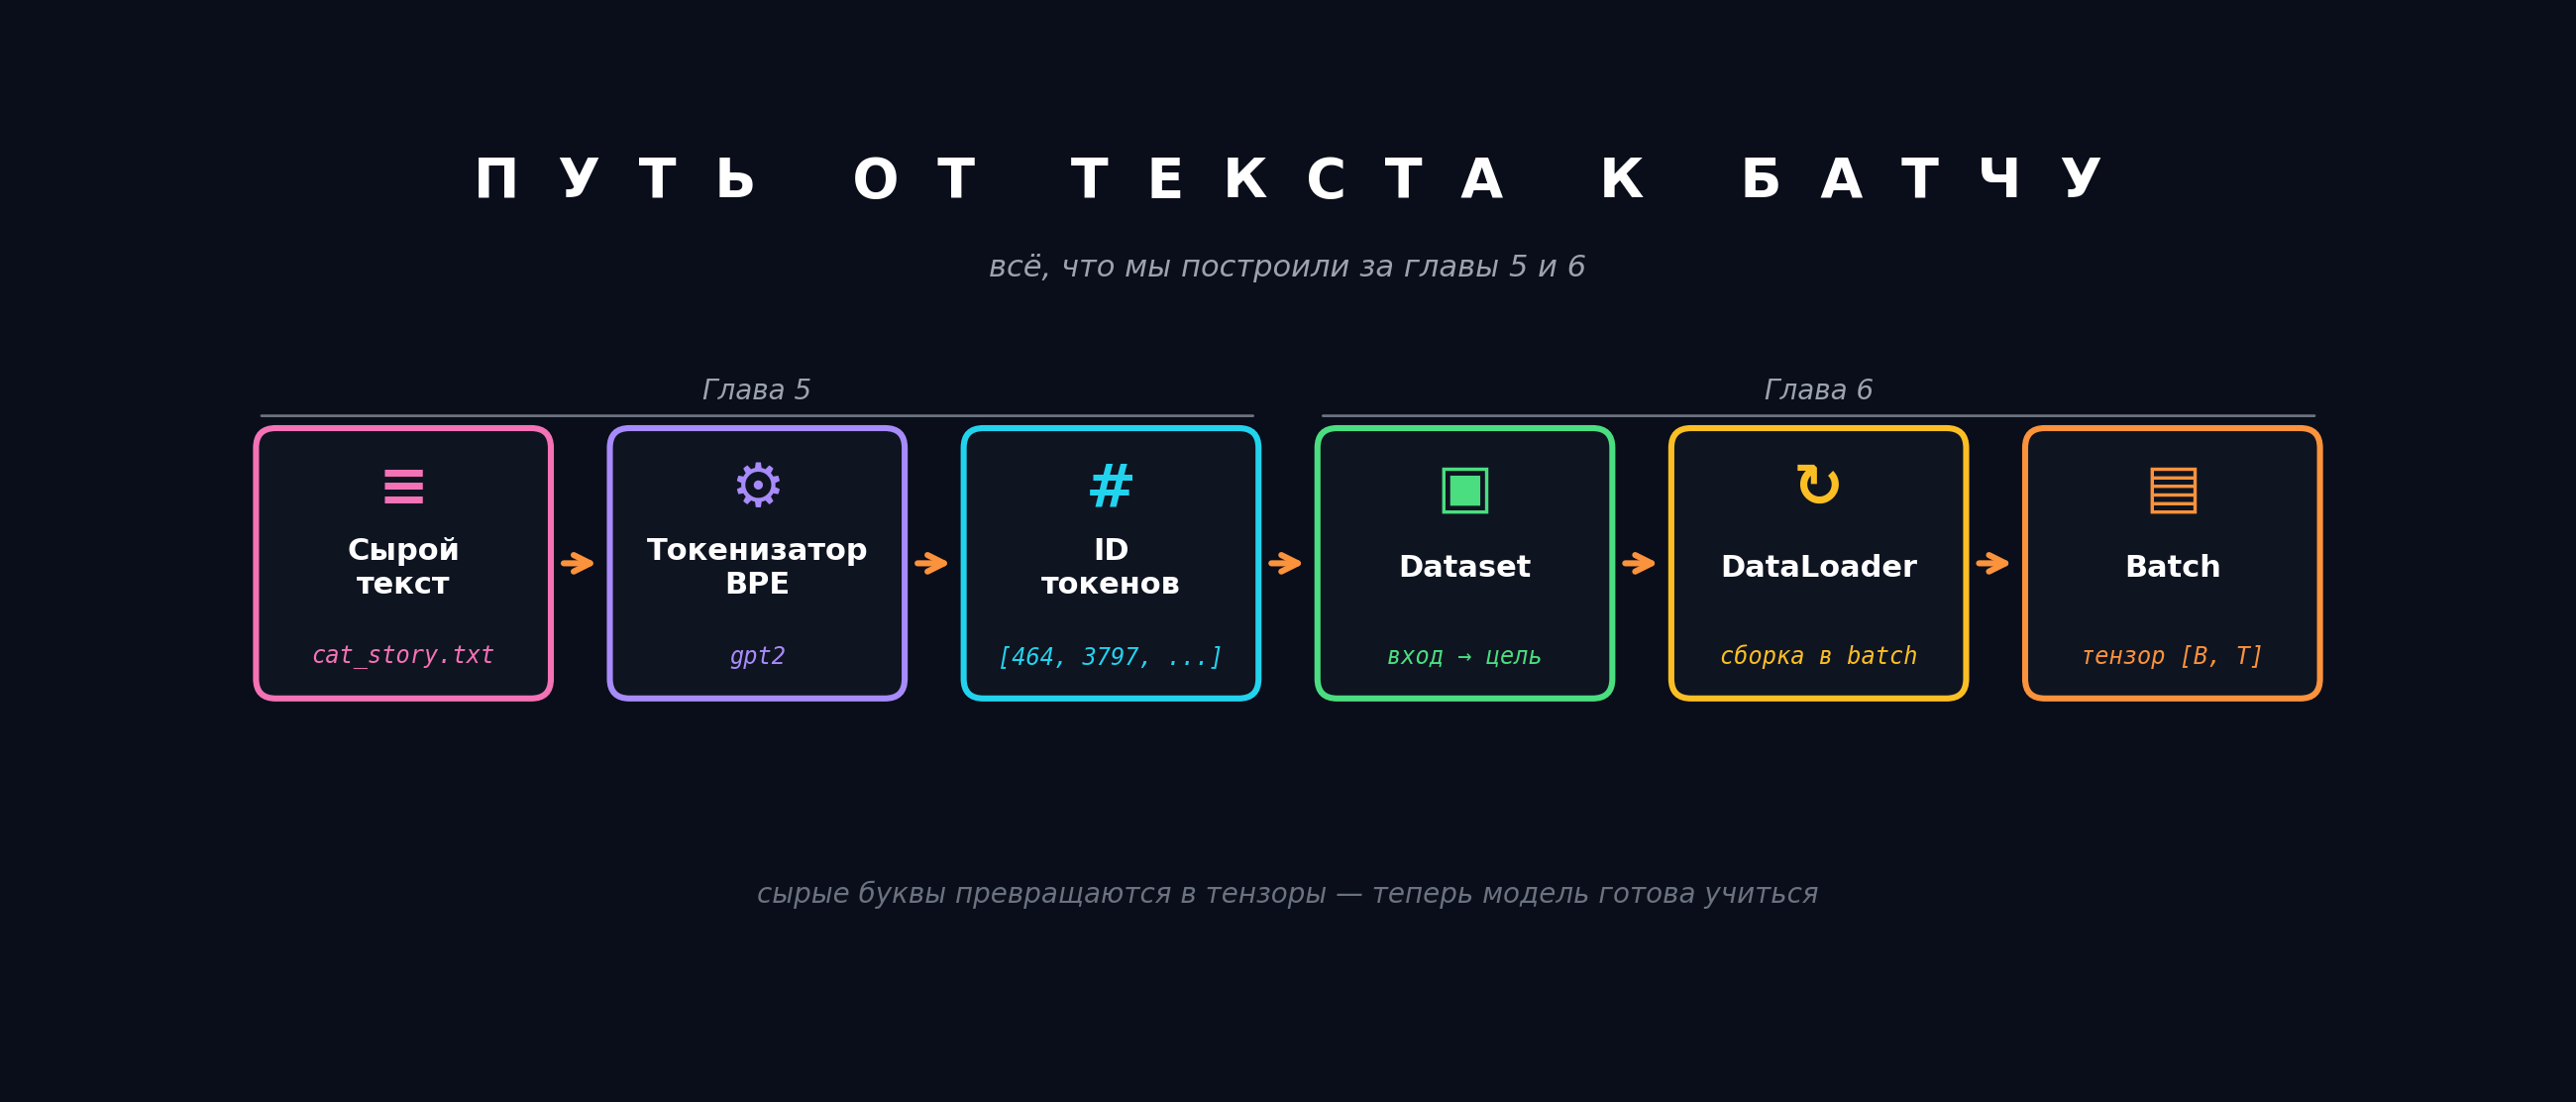

Теперь проведём рефакторинг и будем складывать файлы с кодом отдельно.

Все магические числа (размер окна, размер батча, название модели) мы выносим в отдельный файл. Это позволяет менять настройки обучения в одном месте, не лазая по всему коду. (`config.py`)

Вынесем логику загрузки токенизатора в отдельный модуль. Завтра вы захотите сменить gpt2 на rubert - и вам нужно будет поменять всего одну строчку здесь. (`tokenizer_utils.py`)

`dataset.py` - здесь живет класс SimpleDataset, который мы написали ранее. Теперь он импортирует настройки из config.py.

Логика создания DataLoader тоже заслуживает отдельного места (`loader.py`)

`main.py` - Теперь наш главный файл выглядит очень чисто. Он читается как оглавление процесса: настройка -> загрузка данных -> проверка.